# Proyek Analisis Data: Bike Sharing Dataset


## Menentukan Pertanyaan Bisnis
- Pertanyaan 1: Bagaimana pengaruh musim (season) terhadap jumlah total penyewaan sepeda harian?
- Pertanyaan 2: Bagaimana pola jumlah penyewaan sepeda berdasarkan jam (hour) pada hari kerja (workingday) vs hari libur (non-workingday)?

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan gaya visualisasi
sns.set_theme(style="whitegrid")

Gathering Data

In [9]:
# Memuat data harian dan jam
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

# Menampilkan 5 baris pertama
display(day_df.head())
display(hour_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Assessing Data

In [10]:
# Memeriksa struktur dan tipe data
print("=== Info Day DF ===")
day_df.info()

print("\n=== Info Hour DF ===")
hour_df.info()

# Memeriksa missing values
print("\nMissing values di day_df:\n", day_df.isna().sum())
print("\nMissing values di hour_df:\n", hour_df.isna().sum())

# Memeriksa duplikasi
print("\nJumlah duplikat day_df:", day_df.duplicated().sum())
print("Jumlah duplikat hour_df:", hour_df.duplicated().sum())

# Memeriksa ringkasan statistik
display(day_df.describe())

=== Info Day DF ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB

=== Info Hour DF ===
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
D

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Cleaning Data

In [11]:
# Mengubah tipe kolom dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping nilai kategorikal agar lebih mudah dibaca saat analisis & visualisasi
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_label'] = day_df['season'].map(season_mapping)
hour_df['season_label'] = hour_df['season'].map(season_mapping)

weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice Pellets'}
day_df['weathersit_label'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit_label'] = hour_df['weathersit'].map(weather_mapping)

# Memastikan hasil pembersihan data
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weathersit_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Misty/Cloudy
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Spring,Misty/Cloudy
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Spring,Clear/Partly Cloudy
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Spring,Clear/Partly Cloudy
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Spring,Clear/Partly Cloudy


## Exploratory Data Analysis (EDA)
### Explore Pengaruh Musim dan Pola Penyewaan Jam-jaman

In [12]:
# 1. Eksplorasi Rata-rata Penyewaan Berdasarkan Musim (Pivot Table)
season_summary = day_df.groupby('season_label').agg({
    'casual': ['mean', 'sum'],
    'registered': ['mean', 'sum'],
    'cnt': ['mean', 'median', 'sum', 'std']
}).reset_index()

print("--- Ringkasan Penyewaan per Musim ---")
display(season_summary)

# 2. Eksplorasi Penyewaan Berdasarkan Jam dan Hari Kerja vs Libur (Pivot Table)[cite: 1]
hourly_workingday_summary = hour_df.groupby(['hr', 'workingday']).agg({
    'cnt': 'mean'
}).unstack()

print("--- Ringkasan Rata-Rata Penyewaan per Jam (0=Libur, 1=Hari Kerja) ---")
display(hourly_workingday_summary.head())

--- Ringkasan Penyewaan per Musim ---


season_label       casual           registered                  cnt          \
                       mean     sum         mean     sum         mean  median   
0         Fall  1202.611702  226091  4441.691489  835038  5644.303191  5353.5   
1       Spring   334.928177   60622  2269.204420  410726  2604.132597  2209.0   
2       Summer  1106.097826  203522  3886.233696  715067  4992.331522  4941.5   
3       Winter   729.112360  129782  3999.050562  711831  4728.162921  4634.5   

                         
       sum          std  
0  1061129  1459.800381  
1   471348  1399.942119  
2   918589  1695.977235  
3   841613  1699.615261

--- Ringkasan Rata-Rata Penyewaan per Jam (0=Libur, 1=Hari Kerja) ---


cnt           
workingday          0          1
hr                              
0           90.800000  36.786290
1           69.508696  16.552632
2           53.171053   8.683778
3           25.775330   4.942553
4            8.264317   5.429787

## Visualization & Explanatory Analysis

Pertanyaan 1:

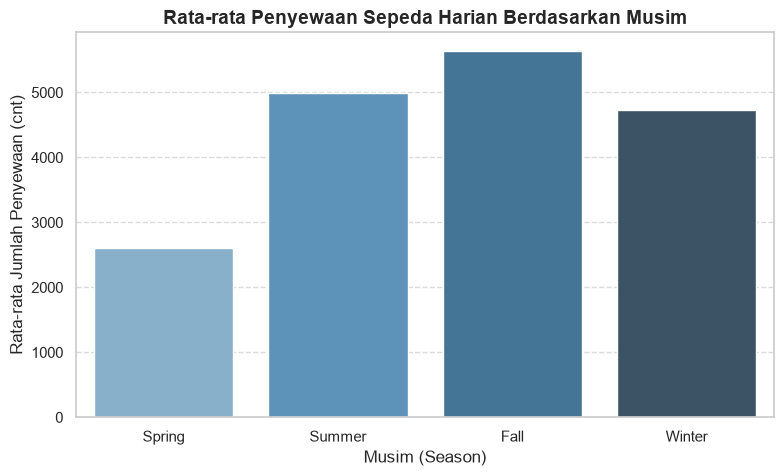

In [13]:
# Visualisasi 1: Rata-rata Penyewaan Sepeda Berdasarkan Musim
plt.figure(figsize=(9, 5))
sns.barplot(
    x='season_label',
    y='cnt',
    data=day_df,
    estimator=np.mean,
    errorbar=None,
    hue='season_label',
    legend=False,
    palette='Blues_d'
)
plt.title('Rata-rata Penyewaan Sepeda Harian Berdasarkan Musim', fontsize=14, fontweight='bold')
plt.xlabel('Musim (Season)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan (cnt)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Pertanyaan 2:

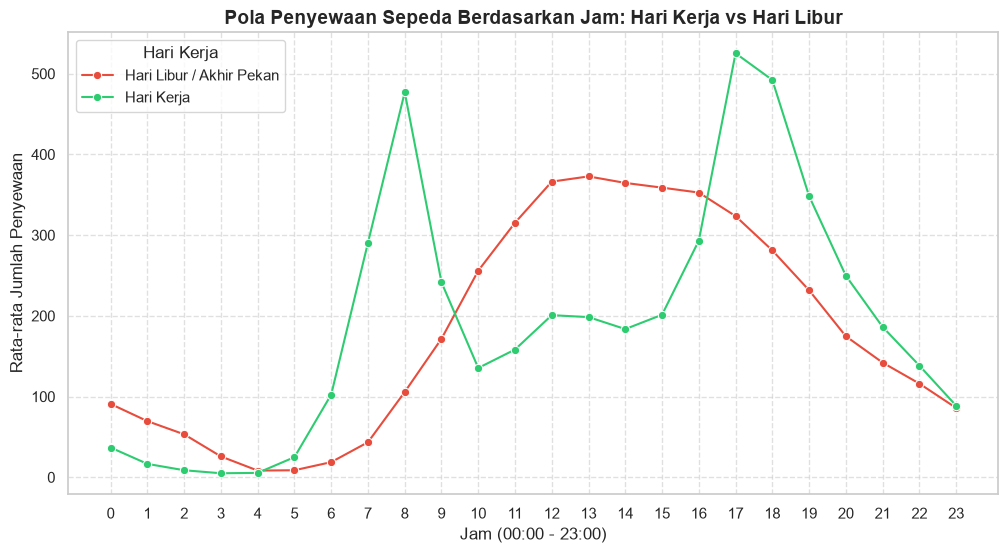

In [14]:
# Visualisasi 2: Pola Penyewaan Berdasarkan Jam pada Hari Kerja vs Hari Libur
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='hr',
    y='cnt',
    hue='workingday',
    data=hour_df,
    palette=['#e74c3c', '#2ecc71'],
    marker='o',
    errorbar=None
)
plt.title('Pola Penyewaan Sepeda Berdasarkan Jam: Hari Kerja vs Hari Libur', fontsize=14, fontweight='bold')
plt.xlabel('Jam (00:00 - 23:00)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Hari Kerja', labels=['Hari Libur / Akhir Pekan', 'Hari Kerja'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Kesimpulan
- **Kesimpulan Pertanyaan 1:** Musim Gugur (*Fall*) merupakan musim dengan rata-rata jumlah penyewaan sepeda harian tertinggi, disusul oleh musim Panas (*Summer*). Sebaliknya, musim Perintis (*Spring*) memiliki tingkat penyewaan paling rendah. Hal ini menunjukkan bahwa faktor iklim dan cuaca yang nyaman pada musim gugur sangat menguntungkan operasional bisnis penyewaan sepeda.
- **Kesimpulan Pertanyaan 2:** Terdapat perbedaan pola penyewaan yang signifikan antara hari kerja dan hari libur. Pada hari kerja (*workingday*), terjadi dua lonjakan utama (*peak hours*) yaitu sekitar **jam 08:00 pagi** dan **jam 17:00 - 18:00 sore**, yang mengindikasikan penggunaan sepeda sebagai moda transportasi komuter untuk berangkat dan pulang kerja/sekolah. Sementara itu, pada hari libur (*non-workingday*), aktivitas penyewaan terdistribusi lebih merata mulai siang hingga sore hari (puncaknya sekitar **jam 12:00 - 16:00**) untuk keperluan rekreasi.